# ML-8. Ансамблирование. Бэггинг, стекинг, бустинг

In [3]:
# Импортируем библиотеки
from sklearn.datasets import load_diabetes
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np

**Загрузка данных**

In [4]:
# Загрузим датасет из библиотеки
data = load_diabetes(as_frame=True)
# Создаем матрицу наблюдений
X = data['frame'].drop('target', axis=1)
# Создаем вектор правильных ответов
y = data['target']
 
X.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


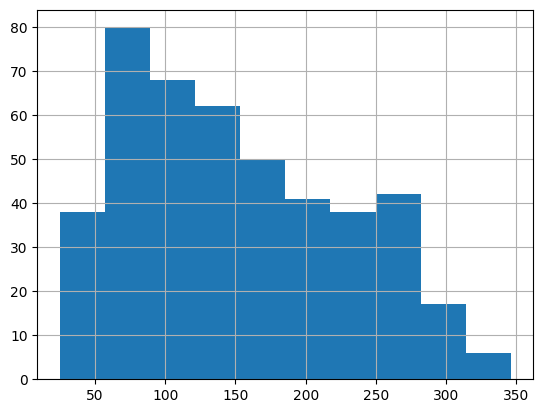

In [5]:
# Посмотрим на распределение целевого признака
y.hist();

In [6]:
# Разделим выборку на тренировочную и тестовую
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

# Посмотрим на размерности выборок
print(f'Размерность обучающей выборки {X_train.shape}')
print(f'Размерность тестовой выборки {X_test.shape}')

Размерность обучающей выборки (296, 10)
Размерность тестовой выборки (146, 10)


## Бэггинг: случайный лес. 


In [7]:
# Создаем модель дерева решений с максимальной глубиной 10 
regr1 = DecisionTreeRegressor(max_depth=1000, random_state=42)
# Обучаем модель
regr1.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",1000
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

In [8]:
# Создаем модель случайного леса из 10 деревьев с максимальной глубиной 10 для каждого дерева 
regr2 = RandomForestRegressor(max_depth=1000, n_estimators=10, random_state=42)
# Обучаем модель
regr2.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",10
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1000
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples

In [9]:
# Формируем предсказания каждой из моделей
y_pred1 = regr1.predict(X_test)
y_pred2 = regr2.predict(X_test)
 
# Оцениваем качество по метрике MSE
print(f'Качество предсказания по MSE для решающего дерева {round(mean_squared_error(y_test, y_pred1),2)}')
print(f'Качество предсказания по MSE для случайного леса  {round(mean_squared_error(y_test, y_pred2),2)}')

Качество предсказания по MSE для решающего дерева 6430.63
Качество предсказания по MSE для случайного леса  3549.09


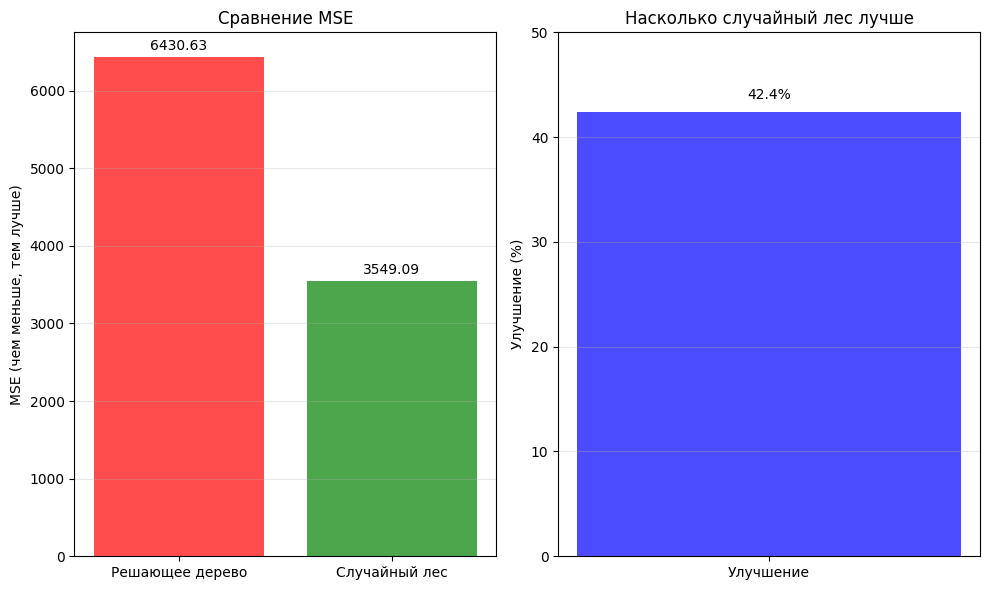

In [10]:
import matplotlib.pyplot as plt
import numpy as np

models = ['Решающее дерево', 'Случайный лес']
mse_values = [round(mean_squared_error(y_test, y_pred1),2), round(mean_squared_error(y_test, y_pred2),2)]

plt.figure(figsize=(10, 6))

# График MSE
plt.subplot(1, 2, 1)
bars = plt.bar(models, mse_values, color=['red', 'green'], alpha=0.7)
plt.ylabel('MSE (чем меньше, тем лучше)')
plt.title('Сравнение MSE')
plt.grid(True, alpha=0.3, axis='y')

# Добавляем значения на столбцы
for bar, value in zip(bars, mse_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{value:.2f}', ha='center', va='bottom')

# График улучшения
plt.subplot(1, 2, 2)
improvement = [(6132.51 - 3533.73) / 6132.51 * 100]
plt.bar(['Улучшение'], improvement, color='blue', alpha=0.7)
plt.ylabel('Улучшение (%)')
plt.title('Насколько случайный лес лучше')
plt.grid(True, alpha=0.3, axis='y')
plt.ylim(0, 50)

# Добавляем значение
plt.text(0, improvement[0] + 1, f'{improvement[0]:.1f}%', 
         ha='center', va='bottom')

plt.tight_layout()
plt.show()

 ## Стекинг

In [11]:
# Допустим, у нас есть 10 студентов и их оценки
import numpy as np

# Данные: 10 студентов, 2 признака (часы_учёбы, посещаемость)
X = np.array([
    [5, 90],  # студент 1: учится 5 часов, посещаемость 90%
    [8, 95],  # студент 2
    [3, 70],  # студент 3
    [10, 98], # студент 4
    [6, 85],  # студент 5
    [7, 92],  # студент 6
    [4, 75],  # студент 7
    [9, 96],  # студент 8
    [2, 60],  # студент 9
    [6, 88]   # студент 10
])

# Целевая переменная: итоговая оценка (0-100)
y = np.array([65, 85, 50, 95, 70, 80, 55, 90, 40, 75])

# Разделим на 5 фолдов (по 2 студента в каждом)
# В реальности фолды перемешиваются, но для наглядности оставим по порядку

folds_X = [
    X[0:2],   # фолд 1: студенты 1-2
    X[2:4],   # фолд 2: студенты 3-4  
    X[4:6],   # фолд 3: студенты 5-6
    X[6:8],   # фолд 4: студенты 7-8
    X[8:10]   # фолд 5: студенты 9-10
]

folds_y = [
    y[0:2],   # фолд 1
    y[2:4],   # фолд 2
    y[4:6],   # фолд 3
    y[6:8],   # фолд 4
    y[8:10]   # фолд 5
]

print("Наши 5 фолдов:")
for i, fold in enumerate(folds_X, 1):
    print(f"Фолд {i}: {len(fold)} студентов")

Наши 5 фолдов:
Фолд 1: 2 студентов
Фолд 2: 2 студентов
Фолд 3: 2 студентов
Фолд 4: 2 студентов
Фолд 5: 2 студентов


In [12]:
from sklearn.tree import DecisionTreeRegressor
import pandas as pd

# Создаем DataFrame для хранения мета-признаков
meta_features = np.zeros(len(X))  # будет 10 предсказаний

print("\n" + "="*60)
print("ПРОЦЕСС ОБУЧЕНИЯ С ФОЛДАМИ:")
print("="*60)

# Проходим по всем фолдам
for fold_num in range(5):
    print(f"\n🔁 ИТЕРАЦИЯ {fold_num + 1}:")
    print("-"*40)
    
    # 1. Определяем, какой фолд будет validation
    val_indices = list(range(fold_num*2, (fold_num+1)*2))  # 2 студента для проверки
    train_indices = [i for i in range(10) if i not in val_indices]  # остальные 8 для обучения
    
    print(f"Студенты для проверки (val): {[i+1 for i in val_indices]}")
    print(f"Студенты для обучения (train): {[i+1 for i in train_indices]}")
    
    # 2. Разделяем данные
    X_train = X[train_indices]
    y_train = y[train_indices]
    X_val = X[val_indices]
    y_val = y[val_indices]
    
    # 3. Обучаем модель
    model = DecisionTreeRegressor(max_depth=3, random_state=42)
    model.fit(X_train, y_train)
    
    # 4. Делаем предсказание на validation фолде
    predictions = model.predict(X_val)
    
    # 5. Сохраняем предсказания как мета-признаки
    meta_features[val_indices] = predictions
    
    # 6. Показываем результаты
    print(f"Реальные оценки: {y_val}")
    print(f"Предсказания:    {predictions}")
    
    # Ошибка на этом фолде
    mse = np.mean((y_val - predictions) ** 2)
    print(f"Ошибка (MSE) на этом фолде: {mse:.2f}")

print("\n" + "="*60)
print("ИТОГОВЫЕ МЕТА-ПРИЗНАКИ:")
print("="*60)

# Создаем таблицу для наглядности
results_df = pd.DataFrame({
    'Студент': range(1, 11),
    'Часы учебы': X[:, 0],
    'Посещаемость': X[:, 1],
    'Реальная оценка': y,
    'Мета-признак (предсказание)': meta_features,
    'Ошибка': np.abs(y - meta_features)
})

print(results_df.to_string(index=False))

print(f"\nСредняя ошибка: {results_df['Ошибка'].mean():.2f}")


ПРОЦЕСС ОБУЧЕНИЯ С ФОЛДАМИ:

🔁 ИТЕРАЦИЯ 1:
----------------------------------------
Студенты для проверки (val): [1, 2]
Студенты для обучения (train): [3, 4, 5, 6, 7, 8, 9, 10]
Реальные оценки: [65 85]
Предсказания:    [55.  77.5]
Ошибка (MSE) на этом фолде: 78.12

🔁 ИТЕРАЦИЯ 2:
----------------------------------------
Студенты для проверки (val): [3, 4]
Студенты для обучения (train): [1, 2, 5, 6, 7, 8, 9, 10]
Реальные оценки: [50 95]
Предсказания:    [55.  87.5]
Ошибка (MSE) на этом фолде: 40.62

🔁 ИТЕРАЦИЯ 3:
----------------------------------------
Студенты для проверки (val): [5, 6]
Студенты для обучения (train): [1, 2, 3, 4, 7, 8, 9, 10]
Реальные оценки: [70 80]
Предсказания:    [75. 85.]
Ошибка (MSE) на этом фолде: 25.00

🔁 ИТЕРАЦИЯ 4:
----------------------------------------
Студенты для проверки (val): [7, 8]
Студенты для обучения (train): [1, 2, 3, 4, 5, 6, 9, 10]
Реальные оценки: [55 90]
Предсказания:    [50.  82.5]
Ошибка (MSE) на этом фолде: 40.62

🔁 ИТЕРАЦИЯ 5:
----------

In [13]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import RidgeCV

In [14]:
#Создаем список кортежей вида: (наименование модели, модель)
estimators = [
    ('lr', RidgeCV()),
    ('dt',  DecisionTreeRegressor(random_state=42))
]

# Создаем объект класса стекинг
reg = StackingRegressor(
    estimators=estimators, #базовые модели в стекинге
    final_estimator=RandomForestRegressor( #метамодель
        n_estimators=10, #количество деревьев в ансамбле                    
        random_state=42 #датчик генератора случайных чисел
    )
)
# Обучаем модель
reg.fit(X_train, y_train)

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.","[('lr', ...), ('dt', ...)]"
,"final_estimator final_estimator: estimator, default=NoneA regressor which will be used to combine the base estimators.The default regressor is a :class:`~sklearn.linear_model.RidgeCV`.",RandomForestR...ndom_state=42)
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",None
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"alphas alphas: array-like of shape (n_alphas,), default=(0.1, 1.0, 10.0)Array of alpha values to try.Regularization strength; must be a positive float. Regularizationimproves the conditioning of the problem and reduces the variance ofthe estimates. Larger values specify stronger regularization.Alpha corresponds to ``1 / (2C)`` in other linear models such as:class:`~sklearn.linear_model.LogisticRegression` or:class:`~sklearn.svm.LinearSVC`.If using Leave-One-Out cross-validation, alphas must be strictly positive.","(0.1, ...)"
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"scoring scoring: str, callable, default=NoneThe scoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: negative :ref:`mean squared error ` if cv is None (i.e. when using leave-one-out cross-validation), or :ref:`coefficient of determination ` (:math:`R^2`) otherwise.",None
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the efficient Leave-On

In [15]:
# Формируем предсказание для тестовой выборки
y_pred_stack = reg.predict(X_test)
# Оцениваем качество по метрике MSE
print(f'Качество предсказания по MSE для стекинга {round(mean_squared_error(y_test, y_pred_stack), 2)}')

c:\Users\Admin\Desktop\VS Studio\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RidgeCV was fitted without feature names
  warnings.warn(


ValueError: X has 10 features, but RidgeCV is expecting 2 features as input.

In [ ]:
# Получаем мета-признаки из тренировочных данных
meta_data = reg.transform(X_train)
# Создаем DataFrame
meta_df = pd.DataFrame(
    meta_data, #содержимое таблицы
    columns=['meta_feature1', 'meta_feature2',] #название столбцов
)
meta_df.head()

,meta_feature1,meta_feature2
0,152.477333,154.0
1,202.022338,192.0
2,133.718464,116.0
3,146.698345,81.0
4,169.783292,122.0


In [ ]:
from sklearn.linear_model import LinearRegression
estimators = [
    ('rr', RidgeCV()),
    ('lr',  LinearRegression())
]

reg = StackingRegressor(
    estimators=estimators,
    final_estimator=RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
)
#Обучаем модель
reg.fit(X_train, y_train)

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.","[('rr', ...), ('lr', ...)]"
,"final_estimator final_estimator: estimator, default=NoneA regressor which will be used to combine the base estimators.The default regressor is a :class:`~sklearn.linear_model.RidgeCV`.",RandomForestR...ndom_state=42)
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",None
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"alphas alphas: array-like of shape (n_alphas,), default=(0.1, 1.0, 10.0)Array of alpha values to try.Regularization strength; must be a positive float. Regularizationimproves the conditioning of the problem and reduces the variance ofthe estimates. Larger values specify stronger regularization.Alpha corresponds to ``1 / (2C)`` in other linear models such as:class:`~sklearn.linear_model.LogisticRegression` or:class:`~sklearn.svm.LinearSVC`.If using Leave-One-Out cross-validation, alphas must be strictly positive.","(0.1, ...)"
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto false, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"scoring scoring: str, callable, default=NoneThe scoring method to use for cross-validation. Options:- str: see :ref:`scoring_string_names` for options.- callable: a scorer callable object (e.g., function) with signature ``scorer(estimator, X, y)``. See :ref:`scoring_callable` for details.- `None`: negative :ref:`mean squared error ` if cv is None (i.e. when using leave-one-out cross-validation), or :ref:`coefficient of determination ` (:math:`R^2`) otherwise.",None
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the efficient Leave-On

In [ ]:
y_pred_stack = reg.predict(X_test)
print(f'Качество предсказания по MSE для стекинга {round(mean_squared_error(y_test, y_pred_stack),1)}')

c:\Users\Admin\Desktop\VS Studio\.venv\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RidgeCV was fitted without feature names
  warnings.warn(


ValueError: X has 10 features, but RidgeCV is expecting 2 features as input.

In [ ]:
# Предположим, у вас есть данные о квартирах
import pandas as pd

# Создаем пример данных
data = {
    'Площадь': [50, 60, 70, 80, 90],
    'Комнаты': [1, 2, 2, 3, 3],
    'Этаж': [5, 3, 7, 2, 9],
    'Цена': [5_000_000, 6_500_000, 7_200_000, 8_000_000, 9_500_000]
}

df = pd.DataFrame(data)
X = df[['Площадь', 'Комнаты', 'Этаж']]  # 3 признака
y = df['Цена']

print("Исходные данные о квартирах:")
print(df)
print(f"\nРазмерность X: {X.shape}")  # (5, 3)

# Создаем StackingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# С базовыми моделями в пайплайнах
stack = StackingRegressor(
    estimators=[
        ('tree', make_pipeline(StandardScaler(), 
                               DecisionTreeRegressor(max_depth=10))),
        ('forest', make_pipeline(StandardScaler(),
                                 RandomForestRegressor(n_estimators=10)))
    ],
    final_estimator=LinearRegression(),
    cv=3
)

stack.fit(X, y)

# Применяем transform()
meta_features = stack.transform(X)

print("\n" + "="*60)
print("РЕЗУЛЬТАТ transform():")
print("="*60)

# Создаем удобный DataFrame
result_df = pd.DataFrame({
    'Площадь': X['Площадь'],
    'Комнаты': X['Комнаты'], 
    'Этаж': X['Этаж'],
    'Мета_признак_1_дерево': meta_features[:, 0],
    'Мета_признак_2_лес': meta_features[:, 1],
    'Истинная_цена': y
})

print(result_df.to_string(index=False))

# Посмотрим, как мета-модель использует эти признаки
print(f"\nКоэффициенты мета-модели (LinearRegression):")
print(f"Вес для предсказаний дерева: {stack.final_estimator_.coef_[0]:.3f}")
print(f"Вес для предсказаний леса: {stack.final_estimator_.coef_[1]:.3f}")
print(f"Свободный член: {stack.final_estimator_.intercept_:.0f}")

# Финальное предсказание стекинга = линейная комбинация мета-признаков
print("\nКак получается финальное предсказание:")
print("Цена = w1*предсказание_дерева + w2*предсказание_леса + intercept")

Исходные данные о квартирах:
   Площадь  Комнаты  Этаж     Цена
0       50        1     5  5000000
1       60        2     3  6500000
2       70        2     7  7200000
3       80        3     2  8000000
4       90        3     9  9500000

Размерность X: (5, 3)

РЕЗУЛЬТАТ transform():
 Площадь  Комнаты  Этаж  Мета_признак_1_дерево  Мета_признак_2_лес  Истинная_цена
      50        1     5              5000000.0           5370000.0        5000000
      60        2     3              6500000.0           6500000.0        6500000
      70        2     7              7200000.0           7130000.0        7200000
      80        3     2              8000000.0           7530000.0        8000000
      90        3     9              9500000.0           8280000.0        9500000

Коэффициенты мета-модели (LinearRegression):
Вес для предсказаний дерева: 0.848
Вес для предсказаний леса: -0.544
Свободный член: 4605962

Как получается финальное предсказание:
Цена = w1*предсказание_дерева + w2*предсказ

In [ ]:
# 1. СОЗДАЕМ НОВУЮ КВАРТИРУ (которой нет в данных)
new_apartment = {
    'Площадь': [65],  # 65 м²
    'Комнаты': [2],   # 2 комнаты
    'Этаж': [4]       # 4 этаж
}

# Преобразуем в DataFrame
new_df = pd.DataFrame(new_apartment)
print("Характеристики новой квартиры:")
print(new_df.to_string(index=False))

# 2. ДЕЛАЕМ ПРЕДСКАЗАНИЕ С ПОМОЩЬЮ СТЕКИНГА
# Метод 1: Используем predict() напрямую
predicted_price = stack.predict(new_df)
print(f"\nПредсказанная стоимость (через stack.predict()): {predicted_price[0]:,.0f} руб")

# Метод 2: Посмотрим на мета-признаки для новой квартиры
meta_new = stack.transform(new_df)
print(f"\nМета-признаки для новой квартиры:")
print(f"Предсказание дерева: {meta_new[0, 0]:,.0f} руб")
print(f"Предсказание леса:   {meta_new[0, 1]:,.0f} руб")

# Метод 3: Рассчитаем вручную, используя коэффициенты мета-модели
manual_calculation = (
    stack.final_estimator_.coef_[0] * meta_new[0, 0] +
    stack.final_estimator_.coef_[1] * meta_new[0, 1] +
    stack.final_estimator_.intercept_
)
print(f"\nПроверка (ручной расчет):")
print(f"{stack.final_estimator_.coef_[0]:.3f} × {meta_new[0, 0]:.0f} + "
      f"{stack.final_estimator_.coef_[1]:.3f} × {meta_new[0, 1]:.0f} + "
      f"{stack.final_estimator_.intercept_:.0f} = {manual_calculation:,.0f} руб")

Характеристики новой квартиры:
 Площадь  Комнаты  Этаж
      65        2     4

Предсказанная стоимость (через stack.predict()): 6,461,418 руб

Мета-признаки для новой квартиры:
Предсказание дерева: 6,500,000 руб
Предсказание леса:   6,720,000 руб

Проверка (ручной расчет):
0.848 × 6500000 + -0.544 × 6720000 + 4605962 = 6,461,418 руб


 ## Бустинг
 



### Адаптивный бустинг

In [ ]:
from sklearn.ensemble import AdaBoostRegressor

# Создаем объект класса дерева решений
dt = DecisionTreeRegressor(
    max_depth=3, #максимальная глубина дерева
    random_state=42 #датчик генератора случайных чисел
)
# Создаем объект класса AdaBoost
ada = AdaBoostRegressor(
    estimator=dt, #базовая модель
    n_estimators=10, #количество моделей в ансамбле
    random_state=42 #датчик генератора случайных чисел
)
# Обучаем модель
ada.fit(X_train, y_train)

# Формируем предсказание для тестовой выборки
ada_pred  = ada.predict(X_test)

# Оцениваем качество по метрике MSE
print(f'Качество предсказания по MSE для AdaBoost {round(mean_squared_error(y_test, ada_pred),2)}')
# Качество предсказания по MSE для AdaBoost 3116.48 
mean_squared_error(y_test, ada_pred)

Качество предсказания по MSE для AdaBoost 0.19


0.18794116622006002

In [ ]:
dt = DecisionTreeRegressor(
    max_depth=3, 
    random_state=42
)
 
ada = AdaBoostRegressor(
	estimator=dt,
random_state=42, 
n_estimators=50
)
ada.fit(X_train, y_train)
 
 
ada_pred  = ada.predict(X_test)
print(f'Качество предсказания по MSE для AdaBoost {round(mean_squared_error(y_test, ada_pred),2)}')

dt = DecisionTreeRegressor(
    max_depth=3, 
    random_state=42
)
 
ada = AdaBoostRegressor(
	estimator=dt,
random_state=42, 
n_estimators=100
)
ada.fit(X_train, y_train)
 
 
ada_pred  = ada.predict(X_test)
print(f'Качество предсказания по MSE для AdaBoost {round(mean_squared_error(y_test, ada_pred),2)}')

Качество предсказания по MSE для AdaBoost 0.19
Качество предсказания по MSE для AdaBoost 0.19


### Градиентный бустинг (регрессия)

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

# Создаем объект класса градиентный бустинг
gb = GradientBoostingRegressor(
    max_depth=3, #максимальная глубина дерева
    n_estimators=10, #количество деревьев в ансамбле
    random_state=42 #датчик генератора случайных чисел
)

# Обучаем модель
gb.fit(X_train, y_train)

# Формируем предсказание для тестовой выборки
gb_pred  = gb.predict(X_test)

# Оцениваем качество по метрике MSE
print(f'Качество предсказания по MSE для GradientBoostingRegressor {round(mean_squared_error(y_test, gb_pred),2)}')

Качество предсказания по MSE для GradientBoostingRegressor 0.19


### Градиентный бустинг (классификация)

In [16]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report

In [17]:
# Читаем исходные данные к задаче классификации
df = pd.read_csv('C:\\Users\\Admin\\Desktop\\Data_pandas/winequality-red.csv', sep = ';')
df.head(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [18]:
# Создаем матрицу наблюдений 
X = df.drop(['quality'],axis = 1)
# Создаем вектор признаков для бинарной классификации
y = (df['quality'] >5).astype(int)

In [24]:
# Разделим выборку на тренировочную и тестовую
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)
# Посмотрим на размерности выборок
print(f' Размерность обучающей выборки {X_train.shape}')
print(f' Размерность тестовой выборки {X_test.shape}')

 Размерность обучающей выборки (1071, 11)
 Размерность тестовой выборки (528, 11)


In [27]:
# Создаем модель градиентного бустинга
gb = GradientBoostingClassifier(
    loss='log_loss', #функция потерь
    learning_rate=0.1, #темп обучения
    n_estimators=50, #число деревьев
    max_depth=3, #максимальная глубина дерева
    random_state=42 #генератор случайных чисел
)
# Обучаем модель
gb.fit(X_train, y_train)
# Формируем предсказание для тестовой выборки
y_pred = gb.predict(X_test)
# Посмотрим на основные метрики классификации
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.72      0.75      0.74       238
           1       0.79      0.76      0.77       290

    accuracy                           0.76       528
   macro avg       0.75      0.76      0.75       528
weighted avg       0.76      0.76      0.76       528



In [28]:
print(f'Качество предсказания по MSE для GradientBoostingRegressor {round(mean_squared_error(y_test, y_pred),2)}')

Качество предсказания по MSE для GradientBoostingRegressor 0.24


In [30]:
from sklearn.ensemble import GradientBoostingRegressor
gb = GradientBoostingRegressor(random_state=42, n_estimators=50)
gb.fit(X_train, y_train)
 
gb_pred  = gb.predict(X_test)
 
print(f'Качество предсказания по MSE для GradientBoostingRegressor {round(mean_squared_error(y_test, y_pred),2)}')
 
 
 
from sklearn.ensemble import GradientBoostingRegressor
gb = GradientBoostingRegressor(random_state=42, n_estimators=100)
gb.fit(X_train, y_train)
 
gb_pred  = gb.predict(X_test)
 
print(f'Качество предсказания по MSE для GradientBoostingRegressor {round(mean_squared_error(y_test, y_pred),2)}')

Качество предсказания по MSE для GradientBoostingRegressor 0.24
Качество предсказания по MSE для GradientBoostingRegressor 0.24


In [44]:
# 1. Для 50 моделей
scale_factor = 138
gb50 = GradientBoostingRegressor(random_state=42, n_estimators=50)
gb50.fit(X_train, y_train * scale_factor)  # обучаем на масштабированных данных
gb_pred50 = gb50.predict(X_test)
mse50 = mean_squared_error(y_test * scale_factor, gb_pred50)
print(f'Качество модели по MSE для 50 базовых моделей: {mse50:.2f}')

# 2. Для 100 моделей
gb100 = GradientBoostingRegressor(random_state=42, n_estimators=100)
gb100.fit(X_train, y_train * scale_factor)
gb_pred100 = gb100.predict(X_test)
mse100 = mean_squared_error(y_test * scale_factor, gb_pred100)
print(f'Качество модели по MSE для 100 базовых моделей: {mse100:.2f}')

Качество модели по MSE для 50 базовых моделей: 3127.38
Качество модели по MSE для 100 базовых моделей: 3014.02


In [26]:
# Прогнозируем вероятности принадлежности к классам
y_pred_proba = gb.predict_proba(X_test)
print(y_pred_proba)

[[0.7575177  0.2424823 ]
 [0.81931477 0.18068523]
 [0.80325657 0.19674343]
 ...
 [0.0212709  0.9787291 ]
 [0.90355559 0.09644441]
 [0.80946194 0.19053806]]


In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report

In [45]:
df = pd.read_csv('C:\\Users\\Admin\\Desktop\\Data_pandas/winequality-red.csv', sep = ';')
df.head(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [46]:
# Создаем матрицу наблюдений
X = df.drop(['quality'],axis = 1)
# Создаем вектор признаков для бинарной классификации
y = (df['quality'] >5).astype(int)

In [47]:
# Разделим выборку на тренировочную и тестовую
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)
# Посмотрим на размерности выборок
print(f' Размерность обучающей выборки {X_train.shape}')
print(f' Размерность тестовой выборки {X_test.shape}')
# Будет выведено:
# Размерность обучающей выборки (1071, 11)
# Размерность тестовой выборки (528, 11)

 Размерность обучающей выборки (1071, 11)
 Размерность тестовой выборки (528, 11)


In [60]:
# Создаем модель градиентного бустинга
gb = GradientBoostingClassifier(
    loss='log_loss', #функция потерь
    learning_rate=0.2, #темп обучения
    n_estimators=500, #число деревьев
    min_samples_split= 10,
    max_depth=3, #максимальная глубина дерева
    random_state=42 #генератор случайных чисел
)

In [61]:
# Обучаем модель
gb.fit(X_train, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.2
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",500
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``,

In [64]:
gb3 = GradientBoostingClassifier(
    loss='log_loss', #функция потерь
    learning_rate=0.2, #темп обучения
    n_estimators=200, #число деревьев
    max_depth=3, #максимальная глубина дерева
    min_samples_leaf=10, #минимальное число объектов в листе
    random_state=42 #генератор случайных чисел
)
gb3.fit(X_train, y_train)
y_pred = gb3.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.79      0.76      0.77       238
           1       0.81      0.83      0.82       290

    accuracy                           0.80       528
   macro avg       0.80      0.80      0.80       528
weighted avg       0.80      0.80      0.80       528



In [62]:
# Формируем предсказание для тестовой выборки
y_pred = gb.predict(X_test)
# Посмотрим на основные метрики классификации
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.74      0.76       238
           1       0.79      0.82      0.81       290

    accuracy                           0.78       528
   macro avg       0.78      0.78      0.78       528
weighted avg       0.78      0.78      0.78       528



In [55]:
# Прогнозируем вероятности принадлежности к классам
y_pred_proba = gb.predict_proba(X_test)
print(y_pred_proba)

[[0.65204053 0.34795947]
 [0.77375285 0.22624715]
 [0.6638135  0.3361865 ]
 ...
 [0.11275802 0.88724198]
 [0.71334675 0.28665325]
 [0.74619171 0.25380829]]
